In [ ]:
# Exploratory Data Analysis
# Import basic libraries
import numpy as np 
import pandas as pd 
# import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Set the Environment
# Ignore Warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#Write out the versions of all packages to requirements.txt
!pip freeze >> requirements.txt

# Remove the restriction on Jupyter that limits the columns displayed (the ... in the middle)
pd.set_option('max_columns',None)
# Docs: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.set_option.html#

# Pretty Display of variables.  for instance, you can call df.head() and df.tail() in the same cell and BOTH display w/o print
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# List of ALL Magic Commands.  To run a magic command %var  --- i.e.:  %env
%lsmagic
# %env  -- list environment variables
# %%time  -- gives you information about how long a cel took to run
# %%timeit -- runs a cell 100,000 times and then gives you the average time the cell will take to run (can be LONG)
# %pdb -- python debugger

# to display nice model diagram
from sklearn import set_config
set_config(display='diagram')

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

print("\n Numpy: " + np.__version__)
print("\n sklearn: " + sklearn.__version__)


 Numpy: 1.22.4

 sklearn: 1.2.1


In [ ]:
df = pd.read_csv("Phishing_Legitimate_full.csv")
df.head(5)

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,NumQueryComponents,NumAmpersand,NumHash,NumNumericChars,NoHttps,RandomString,IpAddress,DomainInSubdomains,DomainInPaths,HttpsInHostname,HostnameLength,PathLength,QueryLength,DoubleSlashInPath,NumSensitiveWords,EmbeddedBrandName,PctExtHyperlinks,PctExtResourceUrls,ExtFavicon,InsecureForms,RelativeFormAction,ExtFormAction,AbnormalFormAction,PctNullSelfRedirectHyperlinks,FrequentDomainNameMismatch,FakeLinkInStatusBar,RightClickDisabled,PopUpWindow,SubmitInfoToEmail,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,21,44,0,0,0,0,0.000,0.250000,1,1,0,0,0,0.0,0,0,0,0,0,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,0,2,1,0,41,1,0,0,0,0,0,17,16,103,0,1,0,0.000,0.000000,0,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,27,24,0,0,0,0,0.375,1.000000,1,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,22,50,0,0,0,1,1.000,0.095238,1,1,0,0,0,0.0,1,0,0,0,1,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,0,0,0,0,2,1,1,0,0,1,0,10,29,0,0,0,0,1.000,1.000000,0,0,0,1,0,0.0,1,0,0,0,0,1,0,0,1,1,-1,0,-1,-1,1


In [ ]:
#getting meta gata information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryComponents                  10000 

In [ ]:
# Pull descriptive statistics from the overall dataset

#CLASS_LABEL is the target column, 1 meaning it is phishing and 0 meaning it is legitmate 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.500000,2886.895680,1.0,2500.750000,5000.500000,7500.250000,10000.0
NumDots,10000.0,2.445100,1.346836,1.0,2.000000,2.000000,3.000000,21.0
SubdomainLevel,10000.0,0.586800,0.751214,0.0,0.000000,1.000000,1.000000,14.0
PathLevel,10000.0,3.300300,1.863241,0.0,2.000000,3.000000,4.000000,18.0
UrlLength,10000.0,70.264100,33.369877,12.0,48.000000,62.000000,84.000000,253.0
NumDash,10000.0,1.818000,3.106258,0.0,0.000000,0.000000,2.000000,55.0
NumDashInHostname,10000.0,0.138900,0.545744,0.0,0.000000,0.000000,0.000000,9.0
AtSymbol,10000.0,0.000300,0.017319,0.0,0.000000,0.000000,0.000000,1.0
TildeSymbol,10000.0,0.013100,0.113709,0.0,0.000000,0.000000,0.000000,1.0
NumUnderscore,10000.0,0.323200,1.114660,0.0,0.000000,0.000000,0.000000,18.0


Quick Analysis:

- 50% of the sites are phishing and 50% are legitmate
- more websites have less number of dashes (mean is way lower than the max value of number of dashes)

In [ ]:
#check for empty values
df.isnull().sum()

id                                    0
NumDots                               0
SubdomainLevel                        0
PathLevel                             0
UrlLength                             0
NumDash                               0
NumDashInHostname                     0
AtSymbol                              0
TildeSymbol                           0
NumUnderscore                         0
NumPercent                            0
NumQueryComponents                    0
NumAmpersand                          0
NumHash                               0
NumNumericChars                       0
NoHttps                               0
RandomString                          0
IpAddress                             0
DomainInSubdomains                    0
DomainInPaths                         0
HttpsInHostname                       0
HostnameLength                        0
PathLength                            0
QueryLength                           0
DoubleSlashInPath                     0


In [ ]:
# Preprocessing before Univariant Analysis
cat_col = [col for col in df.columns if len(df[col].unique()) < 10]
num_col = [col for col in df.columns if len(df[col].unique()) > 10]

In [ ]:
cat_col

['AtSymbol',
 'TildeSymbol',
 'NumHash',
 'NoHttps',
 'RandomString',
 'IpAddress',
 'DomainInSubdomains',
 'DomainInPaths',
 'HttpsInHostname',
 'DoubleSlashInPath',
 'NumSensitiveWords',
 'EmbeddedBrandName',
 'ExtFavicon',
 'InsecureForms',
 'RelativeFormAction',
 'ExtFormAction',
 'AbnormalFormAction',
 'FrequentDomainNameMismatch',
 'FakeLinkInStatusBar',
 'RightClickDisabled',
 'PopUpWindow',
 'SubmitInfoToEmail',
 'IframeOrFrame',
 'MissingTitle',
 'ImagesOnlyInForm',
 'SubdomainLevelRT',
 'UrlLengthRT',
 'PctExtResourceUrlsRT',
 'AbnormalExtFormActionR',
 'ExtMetaScriptLinkRT',
 'PctExtNullSelfRedirectHyperlinksRT',
 'CLASS_LABEL']

In [ ]:
df.nunique()

id                                    10000
NumDots                                  17
SubdomainLevel                           13
PathLevel                                18
UrlLength                               226
NumDash                                  25
NumDashInHostname                        10
AtSymbol                                  2
TildeSymbol                               2
NumUnderscore                            16
NumPercent                               14
NumQueryComponents                       19
NumAmpersand                             16
NumHash                                   2
NumNumericChars                          82
NoHttps                                   2
RandomString                              2
IpAddress                                 2
DomainInSubdomains                        2
DomainInPaths                             2
HttpsInHostname                           1
HostnameLength                           74
PathLength                      

<AxesSubplot:xlabel='CLASS_LABEL', ylabel='count'>

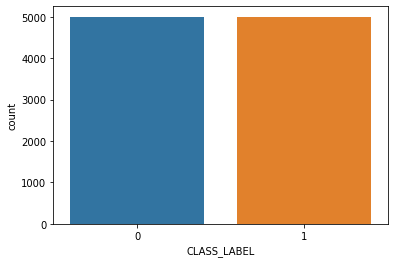

In [ ]:
#analyze CLASS_LABEL
#(Phishing = 1, Legit = 0)
sns.countplot(x="CLASS_LABEL", data=df)

In [ ]:
print(cat_col)

['AtSymbol', 'TildeSymbol', 'NumHash', 'NoHttps', 'RandomString', 'IpAddress', 'DomainInSubdomains', 'DomainInPaths', 'HttpsInHostname', 'DoubleSlashInPath', 'NumSensitiveWords', 'EmbeddedBrandName', 'ExtFavicon', 'InsecureForms', 'RelativeFormAction', 'ExtFormAction', 'AbnormalFormAction', 'FrequentDomainNameMismatch', 'FakeLinkInStatusBar', 'RightClickDisabled', 'PopUpWindow', 'SubmitInfoToEmail', 'IframeOrFrame', 'MissingTitle', 'ImagesOnlyInForm', 'SubdomainLevelRT', 'UrlLengthRT', 'PctExtResourceUrlsRT', 'AbnormalExtFormActionR', 'ExtMetaScriptLinkRT', 'PctExtNullSelfRedirectHyperlinksRT', 'CLASS_LABEL']


<AxesSubplot:xlabel='TildeSymbol', ylabel='count'>

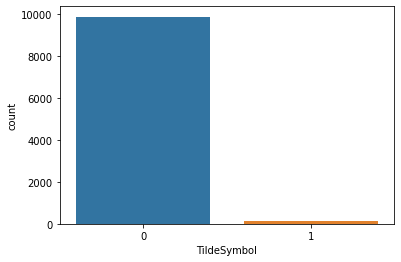

In [ ]:
#(Phishing = 1, Legit = 0)
sns.countplot(x="TildeSymbol", data=df) 

In [ ]:
df['TildeSymbol'].value_counts() #gives percentage

0    9869
1     131
Name: TildeSymbol, dtype: int64

<AxesSubplot:xlabel='IpAddress', ylabel='count'>

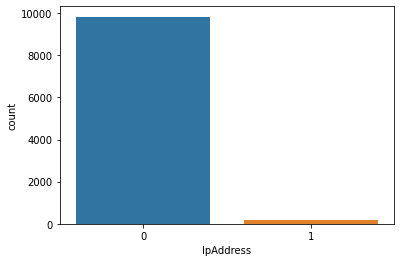

In [ ]:
#analyze AtSymbol
#(Phishing = 1, Legit = 0)
sns.countplot(x="IpAddress", data=df) 

In [ ]:
import pandas as pd
from pandas_profiling import ProfileReport

In [ ]:
#Correlation
sns.set(rc={'figure.figsize':(50,25)})
sns.set_context("talk", font_scale=0.7)

<AxesSubplot:>

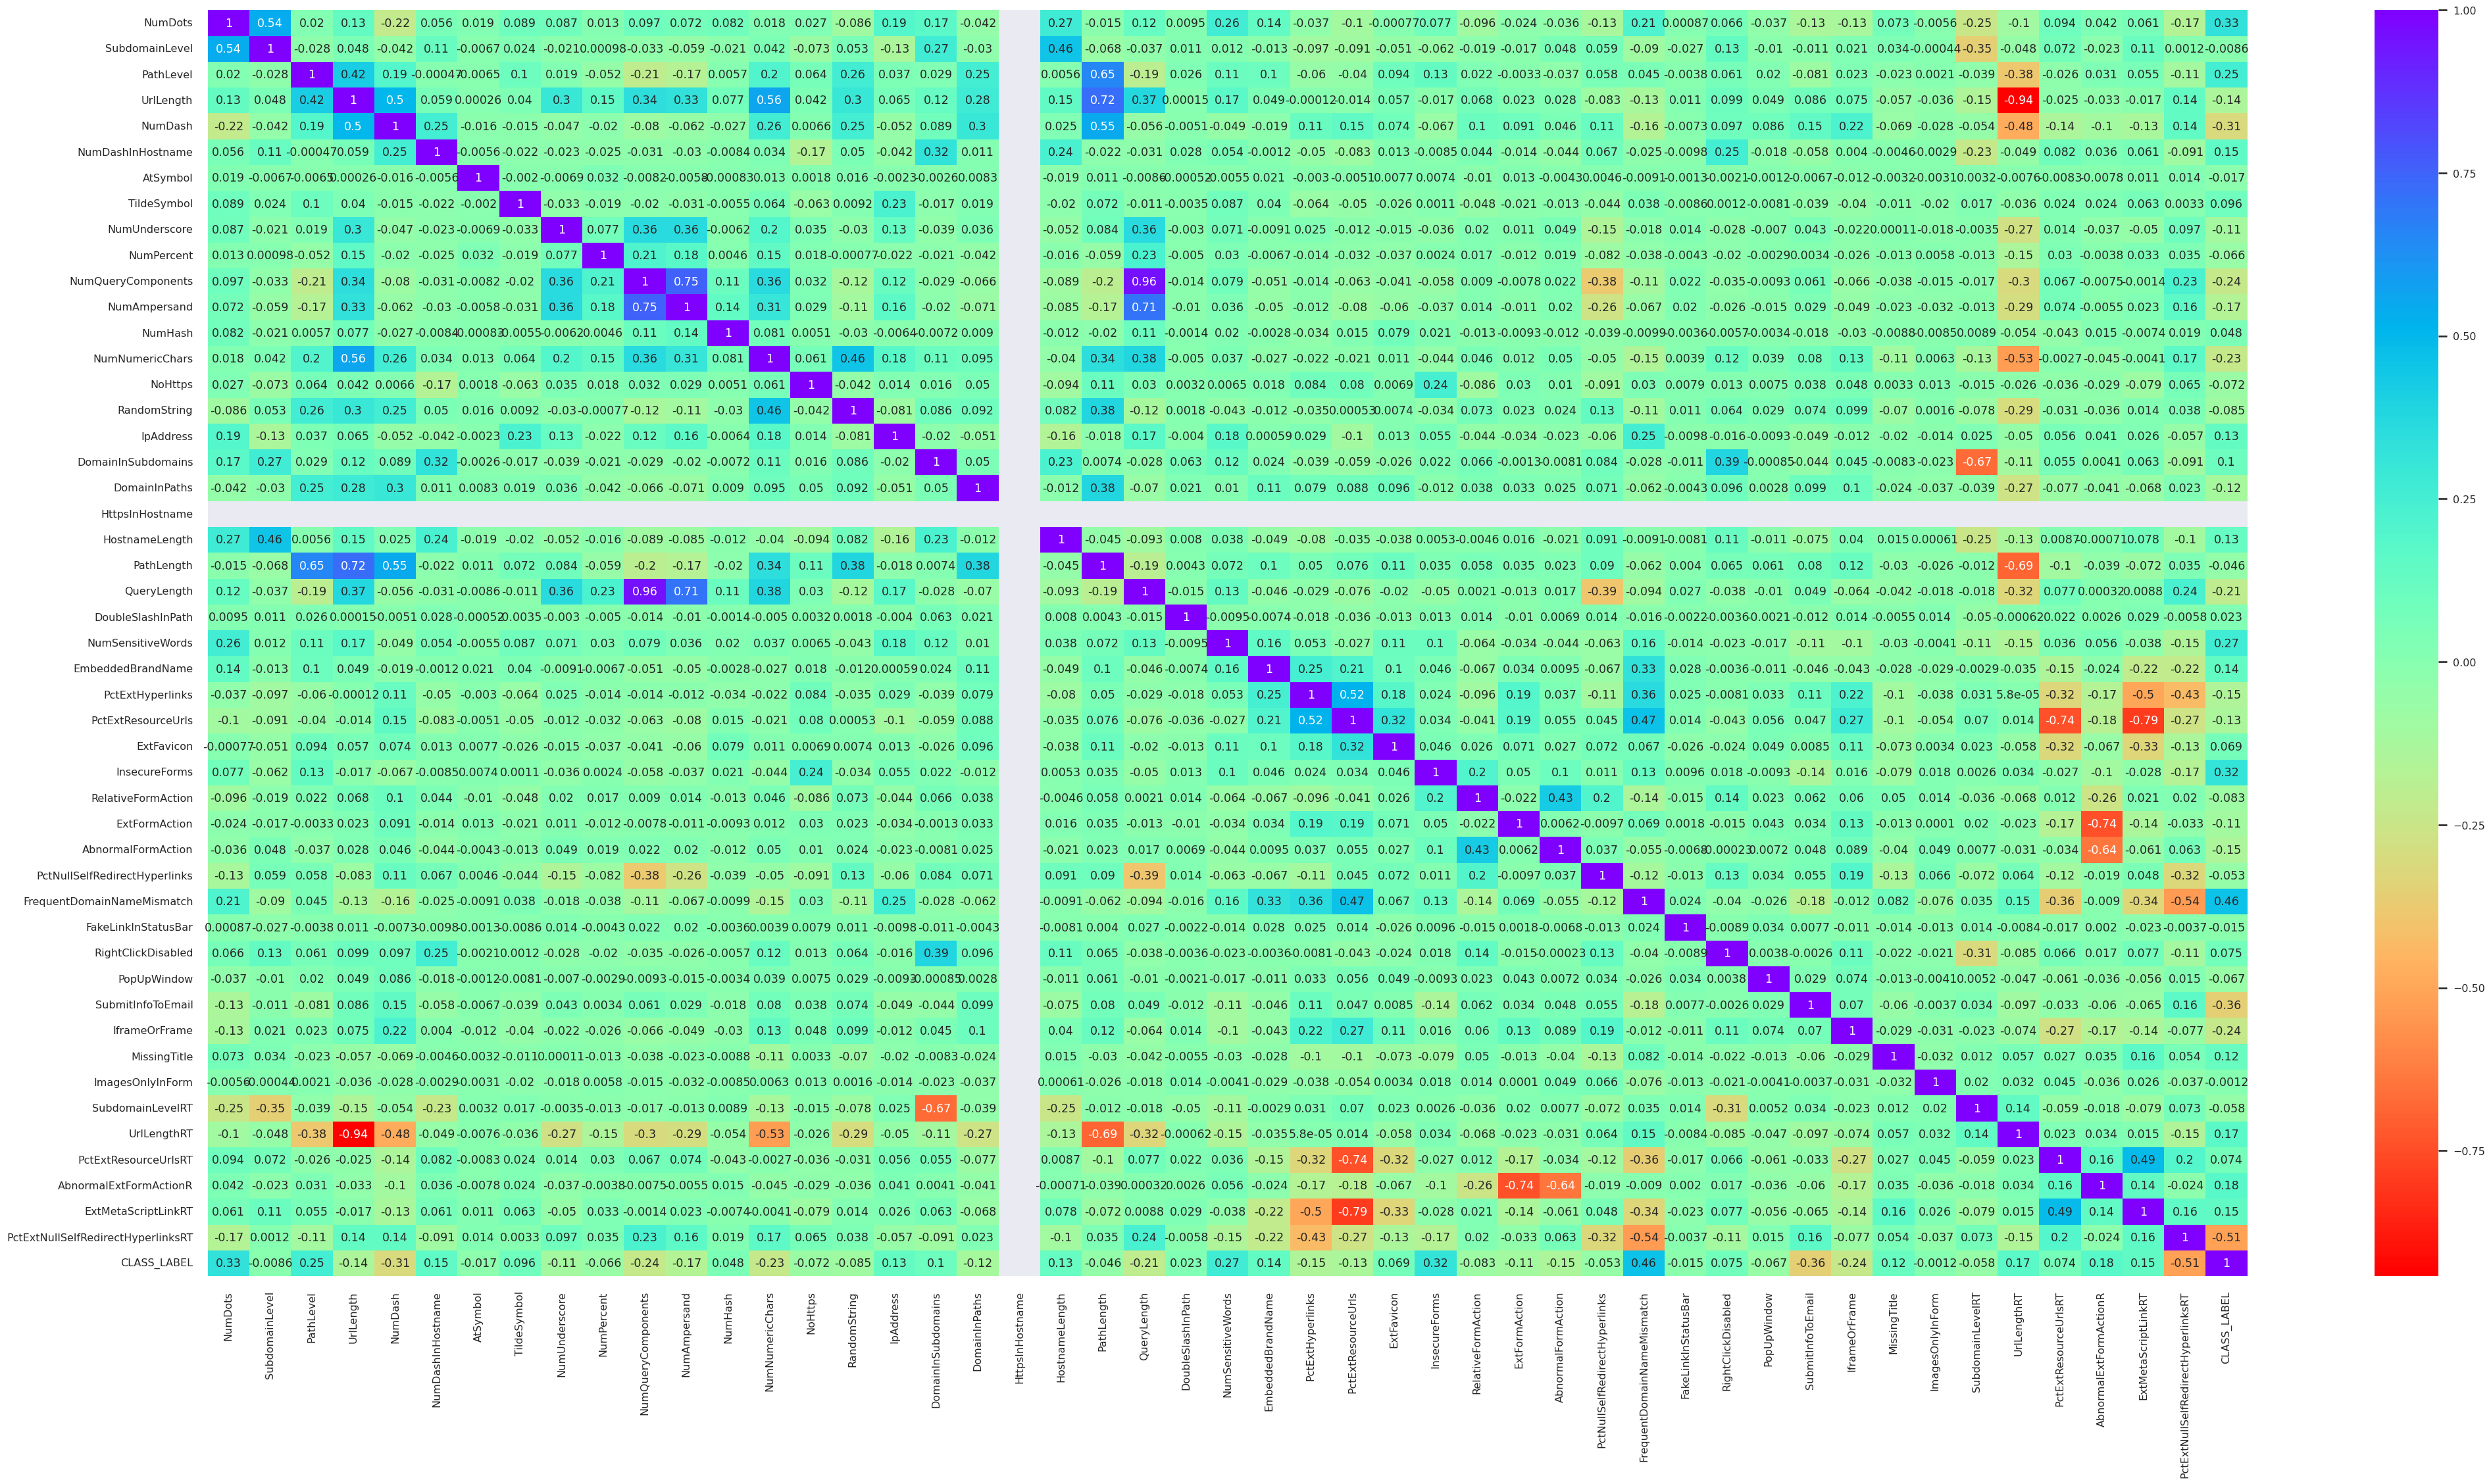

In [ ]:
sns.heatmap(df.iloc[:,1:].corr(method='spearman'), cmap='rainbow_r', annot=True)

In [ ]:
#if your data is normalized, you can use pearson method otherwise use spearman esp if you are not sure of any relationships
df.drop("CLASS_LABEL", axis=1).apply(lambda x: x.corr(df.CLASS_LABEL,method='spearman')).sort_values(ascending=False)

/usr/local/lib/python3.8/dist-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


FrequentDomainNameMismatch            0.463956
NumDots                               0.326268
InsecureForms                         0.316380
NumSensitiveWords                     0.266969
PathLevel                             0.251295
AbnormalExtFormActionR                0.180029
UrlLengthRT                           0.169192
NumDashInHostname                     0.150994
ExtMetaScriptLinkRT                   0.146460
EmbeddedBrandName                     0.141790
IpAddress                             0.132291
HostnameLength                        0.126383
MissingTitle                          0.116693
DomainInSubdomains                    0.100452
TildeSymbol                           0.095864
RightClickDisabled                    0.074900
PctExtResourceUrlsRT                  0.073768
ExtFavicon                            0.069140
NumHash                               0.048014
DoubleSlashInPath                     0.023344
ImagesOnlyInForm                     -0.001165
SubdomainLeve

**Conclusions:**
- FrequentDomainNameMismatch and NumDots are the top predictors of a link being a phishing link 
- If the link does not require you to submit email info or redirects you to another link, it indicates that that is least likely to be a phishing link
- there are columns like pathLevel and URLlength that are so highly correlated and dont add much value to our analysis, as one is the cause of the other.